# Skeleton-Based Human Activity Recognition using ST-GCN
## MSRAction3D Dataset (20 Joints) — LOSO Cross-Validation

This notebook implements a **Spatio-Temporal Graph Convolutional Network (ST-GCN)** for recognizing human activities from skeleton sequences.

**Key Features:**
- Spatial graph convolution using the human body joint adjacency
- Temporal convolution across frames
- Velocity features (frame differences)
- **Leave-One-Subject-Out (LOSO)** cross-validation
- Comprehensive evaluation with confusion matrix

## 1. Installation & Imports

In [1]:
# Install required packages (uncomment if needed)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install torch-geometric
!pip install scikit-learn matplotlib seaborn tqdm numpy

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00a 0:00:01


In [2]:
# Imports

import os, re, copy, glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torch_geometric
from torch_geometric.nn import GCNConv

from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device          : {device}")
print(f"PyTorch         : {torch.__version__}")
print(f"PyG             : {torch_geometric.__version__}")

Device          : cuda
PyTorch         : 2.10.0+cu128
PyG             : 2.7.0


## 2. Configuration & Constants

In [3]:
_candidates = [
    "/kaggle/input/datasets/aininja149/msraction3dskeleton20joints",
    os.path.join(os.getcwd(), "MSRAction3DSkeleton(20joints)"),
]

DATA_DIR = next((p for p in _candidates if os.path.isdir(p)), None)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Dataset not found. Check Kaggle dataset path.\n"
        "Tried:\n" + "\n".join(f"  {p}" for p in _candidates)
    )

print(f"Dataset: {DATA_DIR}")

OUTPUT_DIR = "/kaggle/working/"   # Kaggle writes outputs here


NUM_JOINTS   = 20
NUM_ACTIONS  = 20
IN_CHANNELS  = 3
MAX_FRAMES   = 60
ALL_SUBJECTS = list(range(1, 11))

BATCH_SIZE    = 32
NUM_EPOCHS    = 80
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4

JOINT_NAMES = [
    "Hip Center", "Spine", "Shoulder Center", "Head",
    "Shoulder Left", "Elbow Left", "Wrist Left", "Hand Left",
    "Shoulder Right", "Elbow Right", "Wrist Right", "Hand Right",
    "Hip Left", "Knee Left", "Ankle Left", "Foot Left",
    "Hip Right", "Knee Right", "Ankle Right", "Foot Right",
]

ACTION_NAMES = [
    "High Arm Wave", "Horizontal Arm Wave", "Hammer", "Hand Catch",
    "Forward Punch", "High Throw", "Draw X", "Draw Tick", "Draw Circle",
    "Hand Clap", "Two Hand Wave", "Side Boxing", "Bend", "Forward Kick",
    "Side Kick", "Jogging", "Tennis Swing", "Tennis Serve",
    "Golf Swing", "Pickup & Throw",
]

print(f"Max frames : {MAX_FRAMES} | Subjects : {ALL_SUBJECTS}")

Dataset: /kaggle/input/datasets/aininja149/msraction3dskeleton20joints
Max frames : 60 | Subjects : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## 3. Define Human Body Graph (Adjacency)

In [4]:
def build_body_adjacency():
    edges = [
        (0,1),(1,2),(2,3),              # torso
        (2,4),(4,5),(5,6),(6,7),        # left arm
        (2,8),(8,9),(9,10),(10,11),     # right arm
        (0,12),(12,13),(13,14),(14,15), # left leg
        (0,16),(16,17),(17,18),(18,19), # right leg
    ]
    all_edges = [(s,d) for s,d in edges] + [(d,s) for s,d in edges]
    all_edges += [(i,i) for i in range(NUM_JOINTS)]   # self-loops
    return torch.tensor(all_edges, dtype=torch.long).t().contiguous()

edge_index = build_body_adjacency()
print(f"edge_index shape : {edge_index.shape}  ({edge_index.shape[1]} edges incl. self-loops)")

edge_index shape : torch.Size([2, 58])  (58 edges incl. self-loops)


## 4. Data Loading & Preprocessing

In [5]:
def parse_skeleton_file(filepath):
    """(T*20, 4) → (T, 20, 3)  xyz only."""
    data = np.loadtxt(filepath)
    if data.shape[0] % NUM_JOINTS != 0:
        raise ValueError(
            f"{filepath}: rows {data.shape[0]} not divisible by {NUM_JOINTS}"
        )
    return data[:, :3].reshape(-1, NUM_JOINTS, 3)

def normalize_skeleton(skeleton):
    """Center at joint 0 (hip), scale to unit std."""
    centered = skeleton - skeleton[:, 0:1, :]
    std = centered.std()
    return centered / std if std > 1e-6 else centered

def compute_velocity(skeleton):
    """Frame-to-frame differences; last frame = 0."""
    vel = np.zeros_like(skeleton)
    vel[:-1] = skeleton[1:] - skeleton[:-1]
    return vel

def pad_or_truncate(seq, max_frames):
    T = seq.shape[0]
    if T >= max_frames:
        return seq[:max_frames]
    pad = np.zeros((max_frames - T,) + seq.shape[1:], dtype=seq.dtype)
    return np.concatenate([seq, pad], axis=0)


# SAFE FILE DETECTION

# Find all skeleton files (works regardless of folder structure)
_skeleton_files = glob.glob(os.path.join(DATA_DIR, "**", "*.txt"), recursive=True)

if len(_skeleton_files) == 0:
    raise FileNotFoundError(
        f"No .txt skeleton files found in: {DATA_DIR}"
    )

# Pick first file for sanity check
_f = _skeleton_files[0]

print("Sample file used:", _f)


# SANITY CHECK

_s = parse_skeleton_file(_f)
print(f"Raw skeleton   : {_s.shape}")

_n = normalize_skeleton(_s)
print(f"After norm     : mean={_n.mean():.4f}  std={_n.std():.4f}")

print(f"Velocity shape : {compute_velocity(_n).shape}")

Sample file used: /kaggle/input/datasets/aininja149/msraction3dskeleton20joints/MSRAction3DSkeleton(20joints)/a07/a07_s03_e03_skeleton.txt
Raw skeleton   : (51, 20, 3)
After norm     : mean=0.1037  std=1.0000
Velocity shape : (51, 20, 3)


## 5. Load Entire Dataset

In [6]:
def extract_action_subject_trial(fname):
    """
    Tries multiple MSRAction3D naming conventions.
    Falls back safely instead of skipping everything.
    """

    # Pattern 1: a01_s01_e01
    m = re.search(r"a(\d+)_s(\d+)_e(\d+)", fname, re.IGNORECASE)
    if m:
        return int(m.group(1)), int(m.group(2)), int(m.group(3))

    # Pattern 2: A01_S01_E01
    m = re.search(r"A(\d+)_S(\d+)_E(\d+)", fname, re.IGNORECASE)
    if m:
        return int(m.group(1)), int(m.group(2)), int(m.group(3))

    # Pattern 3: A01S01P01R01A01.skeleton style (fallback)
    m = re.search(r"A(\d+).*S(\d+).*P(\d+).*R(\d+).*A(\d+)", fname, re.IGNORECASE)
    if m:
        return int(m.group(5)), int(m.group(3)), int(m.group(4))

    return None


def load_msr_action3d(data_dir, max_frames=MAX_FRAMES):
    samples, skipped = [], 0

    # search ALL files recursively (fixes your issue)
    all_files = []
    for root, _, files in os.walk(data_dir):
        for f in files:
            all_files.append(os.path.join(root, f))

    print(f"Total files found: {len(all_files)}")

    for fpath in all_files:
        if not fpath.endswith((".txt", ".skeleton")):
            continue

        info = extract_action_subject_trial(os.path.basename(fpath))
        if info is None:
            skipped += 1
            continue

        aid, sid, tid = info

        try:
            skel = parse_skeleton_file(fpath)
        except Exception as e:
            print(f"  [SKIP] {fpath}: {e}")
            skipped += 1
            continue

        if skel.shape[0] < 5:
            skipped += 1
            continue

        norm = normalize_skeleton(skel)
        vel  = compute_velocity(norm)
        feat = np.concatenate([norm, vel], axis=-1)

        samples.append({
            "features": pad_or_truncate(feat, max_frames),
            "position": pad_or_truncate(norm, max_frames),
            "action": aid - 1,
            "subject": sid,
            "trial": tid,
            "filename": os.path.basename(fpath),
        })

    print(f"\nLoaded {len(samples)} samples | Skipped {skipped}")
    return samples


all_samples = load_msr_action3d(DATA_DIR)

# STATS (SAFE)

actions_count = defaultdict(int)
subjects_count = defaultdict(int)

for s in all_samples:
    actions_count[s["action"]] += 1
    subjects_count[s["subject"]] += 1

print("\nSamples per action:")
for a in sorted(actions_count):
    print(f"Action {a}: {actions_count[a]}")

print("\nSubjects found:", sorted(subjects_count.keys()))

Total files found: 567

Loaded 567 samples | Skipped 0

Samples per action:
Action 0: 27
Action 1: 27
Action 2: 27
Action 3: 26
Action 4: 26
Action 5: 26
Action 6: 28
Action 7: 30
Action 8: 30
Action 9: 30
Action 10: 30
Action 11: 30
Action 12: 30
Action 13: 30
Action 14: 20
Action 15: 30
Action 16: 30
Action 17: 30
Action 18: 30
Action 19: 30

Subjects found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


## 6. PyTorch Dataset Class

In [7]:
# PyTorch Dataset
class SkeletonDataset(Dataset):
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        s = self.samples[idx]
        return (
            torch.tensor(s["features"], dtype=torch.float32),
            torch.tensor(s["action"],   dtype=torch.long),
        )

print("SkeletonDataset defined.")

SkeletonDataset defined.


## 7. ST-GCN Model Architecture

The model has two key blocks:
1. **Spatial Graph Convolution**: Applies GCN per frame using the body adjacency.
2. **Temporal Convolution**: Applies 1D convolution along the time axis to capture temporal dynamics.

In [8]:
# ST-GCN Model Architecture

class SpatialGraphConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.gcn = GCNConv(in_ch, out_ch)
        self.bn  = nn.BatchNorm1d(out_ch)

    def forward(self, x, edge_index):
        B, T, N, C = x.shape
        x_flat = x.reshape(B * T * N, C)
        num_g  = B * T
        offsets = torch.arange(num_g, device=x.device).unsqueeze(1) * N
        ei_b = edge_index.unsqueeze(0).expand(num_g, -1, -1) + offsets.unsqueeze(1)
        ei_b = ei_b.reshape(2, -1)
        out = F.relu(self.bn(self.gcn(x_flat, ei_b)))
        return out.reshape(B, T, N, -1)


class TemporalConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=9, stride=1):
        super().__init__()
        pad = (kernel_size - 1) // 2
        self.conv = nn.Conv2d(in_ch, out_ch, (kernel_size, 1), (stride, 1), (pad, 0))
        self.bn   = nn.BatchNorm2d(out_ch)

    def forward(self, x):
        x = x.permute(0, 3, 1, 2)        # (B, C, T, N)
        x = F.relu(self.bn(self.conv(x)))
        return x.permute(0, 2, 3, 1)     # (B, T, N, C)


class STGCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, tk=9, stride=1):
        super().__init__()
        self.spatial  = SpatialGraphConv(in_ch, out_ch)
        self.temporal = TemporalConv(out_ch, out_ch, tk, stride)
        self.dropout  = nn.Dropout(0.25)
        self.residual = (
            nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, (stride, 1)),
                nn.BatchNorm2d(out_ch),
            )
            if in_ch != out_ch or stride != 1
            else nn.Identity()
        )

    def forward(self, x, edge_index):
        if isinstance(self.residual, nn.Identity):
            res = x
        else:
            res = self.residual(x.permute(0, 3, 1, 2)).permute(0, 2, 3, 1)
        out = self.dropout(self.temporal(self.spatial(x, edge_index)))
        return F.relu(out + res)


class STGCN(nn.Module):
    def __init__(self, in_ch, num_classes, edge_index):
        super().__init__()
        self.register_buffer("edge_index", edge_index)
        self.input_bn = nn.BatchNorm1d(in_ch * NUM_JOINTS)
        self.blocks = nn.ModuleList([
            STGCNBlock(in_ch, 64),
            STGCNBlock(64,  64),
            STGCNBlock(64,  128),
            STGCNBlock(128, 128),
            STGCNBlock(128, 256),
            STGCNBlock(256, 256),
        ])
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        B, T, N, C = x.shape
        x = self.input_bn(x.reshape(B * T, N * C)).reshape(B, T, N, C)
        for blk in self.blocks:
            x = blk(x, self.edge_index)
        return self.fc(x.mean(dim=[1, 2]))

# Smoke test
_m = STGCN(6, NUM_ACTIONS, edge_index)
print(f"Parameters: {sum(p.numel() for p in _m.parameters()):,}")
del _m

Parameters: 1,729,092


## 8. Training & Evaluation Helpers

In [9]:
# Training & Evaluation Helpers

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for feats, labels in loader:
        feats, labels = feats.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(feats), labels)
        loss.backward(); optimizer.step()
        preds = model(feats).detach().argmax(1)   # reuse forward — or cache logits
        total_loss += loss.item() * feats.size(0)
        correct    += (preds == labels).sum().item()
        total      += feats.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0., 0, 0
    all_preds, all_labels = [], []
    for feats, labels in loader:
        feats, labels = feats.to(device), labels.to(device)
        logits = model(feats)
        loss   = criterion(logits, labels)
        preds  = logits.argmax(1)
        total_loss += loss.item() * feats.size(0)
        correct    += (preds == labels).sum().item()
        total      += feats.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels

print("Helpers defined.")

Helpers defined.


## 9. Leave-One-Subject-Out (LOSO) Cross-Validation

For each fold, **one subject** is held out as the test set, and all remaining subjects are used for training. A fresh model is trained from scratch for each fold. Results are aggregated across all folds.

In [10]:
import time
import copy
import os
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from tqdm import tqdm

start_time = time.time()

subjects_with_data = sorted(set(s["subject"] for s in all_samples))
num_folds = len(subjects_with_data)

print(f"Subjects: {subjects_with_data}  |  Folds: {num_folds}  |  Epochs/fold: {NUM_EPOCHS}")

MODEL_DIR = "loso_models"
os.makedirs(MODEL_DIR, exist_ok=True)

loso_results = {}
all_fold_preds = []
all_fold_labels = []
fold_histories = {}

for fold_idx, test_subj in enumerate(subjects_with_data):

    print(f"\nFOLD {fold_idx+1}/{num_folds}  —  Test Subject: {test_subj}")

    train_s = [s for s in all_samples if s["subject"] != test_subj]
    test_s = [s for s in all_samples if s["subject"] == test_subj]

    if not test_s:
        print(f"  [SKIP] No samples for subject {test_subj}")
        continue

    print(f"  Train: {len(train_s)}  |  Test: {len(test_s)}")

    train_loader = DataLoader(
        SkeletonDataset(train_s),
        batch_size=BATCH_SIZE,
        shuffle=True,
        drop_last=False
    )

    test_loader = DataLoader(
        SkeletonDataset(test_s),
        batch_size=BATCH_SIZE,
        shuffle=False,
        drop_last=False
    )

    torch.manual_seed(SEED)

    model = STGCN(6, NUM_ACTIONS, edge_index).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=30, gamma=0.5
    )

    best_acc = 0.0
    best_epoch = 0
    best_state = None

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc=f"Subject {test_subj}", leave=False):

        tr_loss, tr_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        te_loss, te_acc, _, _ = evaluate(
            model, test_loader, criterion, device
        )

        scheduler.step()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["test_loss"].append(te_loss)
        history["test_acc"].append(te_acc)

        if te_acc > best_acc:
            best_acc = te_acc
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch % 20 == 0:
            print(
                f"  Ep {epoch:3d} | "
                f"tr_loss {tr_loss:.4f} | tr_acc {tr_acc:.2%} | "
                f"te_acc {te_acc:.2%}"
            )

    model.load_state_dict(best_state)

    model_path = os.path.join(MODEL_DIR, f"stgcn_subject_{test_subj}.pth")

    torch.save({
        "model_state_dict": best_state,
        "subject": test_subj,
        "best_epoch": best_epoch,
        "accuracy": best_acc
    }, model_path)

    print(f"  Saved model → {model_path}")

    _, fold_acc, fold_preds, fold_labels = evaluate(
        model, test_loader, criterion, device
    )

    loso_results[test_subj] = {
        "accuracy": fold_acc,
        "best_epoch": best_epoch,
        "num_test": len(test_s),
        "preds": fold_preds,
        "labels": fold_labels,
    }

    fold_histories[test_subj] = history
    all_fold_preds.extend(fold_preds)
    all_fold_labels.extend(fold_labels)

    print(f"  >> Best accuracy: {fold_acc:.2%} (epoch {best_epoch})")

print("LOSO COMPLETE")

total_time = time.time() - start_time
print(f"TOTAL TRAINING TIME: {total_time:.2f} seconds")

Subjects: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  |  Folds: 10  |  Epochs/fold: 80

FOLD 1/10  —  Test Subject: 1
  Train: 507  |  Test: 60


Subject 1:   1%|▏         | 1/80 [00:06<07:57,  6.04s/it]

  Ep   1 | tr_loss 3.1185 | tr_acc 8.68% | te_acc 6.67%


Subject 1:  25%|██▌       | 20/80 [01:10<03:29,  3.49s/it]

  Ep  20 | tr_loss 2.1271 | tr_acc 36.69% | te_acc 28.33%


...

Subject 10:  50%|█████     | 40/80 [02:25<02:25,  3.64s/it]

  Ep  40 | tr_loss 1.4517 | tr_acc 59.37% | te_acc 56.67%


Subject 10:  75%|███████▌  | 60/80 [03:38<01:12,  3.64s/it]

  Ep  60 | tr_loss 1.2814 | tr_acc 61.74% | te_acc 63.33%


  Ep  80 | tr_loss 1.1068 | tr_acc 71.99% | te_acc 60.00%
  Saved model → loso_models/stgcn_subject_10.pth
  >> Best accuracy: 65.00% (epoch 65)
LOSO COMPLETE
TOTAL TRAINING TIME: 2926.68 seconds


## 10. LOSO Results Summary

In [11]:

print(f"{'Subject':>8} | {'Test N':>6} | {'Best Ep':>7} | {'Acc':>8}")
print("-" * 40)

fold_accs, total_correct, total_n = [], 0, 0
for subj in sorted(loso_results):
    r = loso_results[subj]
    fold_accs.append(r["accuracy"])
    total_correct += sum(p == l for p, l in zip(r["preds"], r["labels"]))
    total_n += r["num_test"]
    print(f"{subj:>8} | {r['num_test']:>6} | {r['best_epoch']:>7} | {r['accuracy']:>7.2%}")

mean_acc    = np.mean(fold_accs)
std_acc     = np.std(fold_accs)
overall_acc = total_correct / total_n

print("-" * 40)
print(f"  Mean  acc : {mean_acc:.2%} ± {std_acc:.2%}")
print(f"  Pooled acc: {overall_acc:.2%}")

 Subject | Test N | Best Ep |      Acc
----------------------------------------
       1 |     60 |      67 |  73.33%
       2 |     59 |      71 |  42.37%
       3 |     56 |      70 |  48.21%
       4 |     38 |      70 |  81.58%
       5 |     57 |      75 |  52.63%
       6 |     58 |      77 |  60.34%
       7 |     59 |      72 |  57.63%
       8 |     60 |      76 |  66.67%
       9 |     60 |      65 |  65.00%
      10 |     60 |      65 |  65.00%
----------------------------------------
  Mean  acc : 61.28% ± 11.10%
  Pooled acc: 60.67%


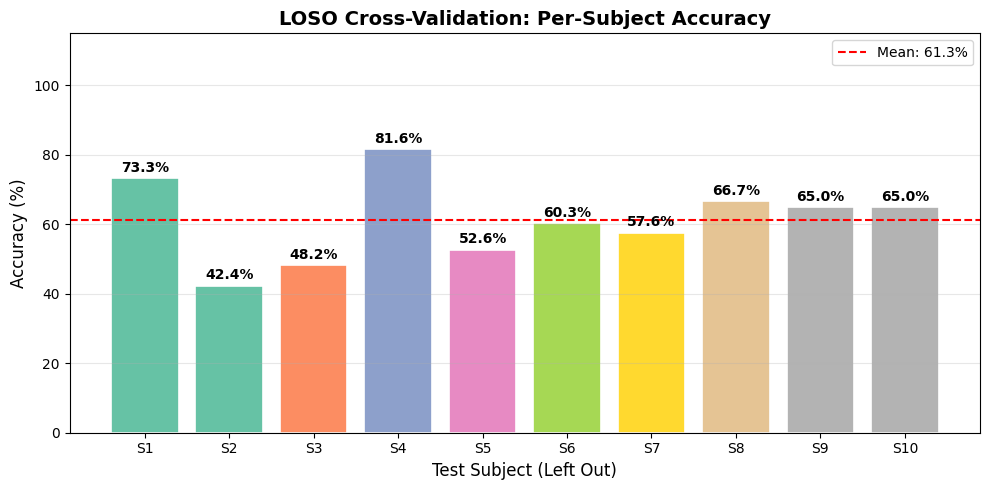

In [12]:
# Per-Subject Accuracy Bar Chart

subjects_sorted = sorted(loso_results)
accs = [loso_results[s]["accuracy"] * 100 for s in subjects_sorted]
colors = plt.cm.Set2(np.linspace(0, 1, len(subjects_sorted)))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([f"S{s}" for s in subjects_sorted], accs,
              color=colors, edgecolor="white", linewidth=1.2)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            f"{acc:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(mean_acc * 100, color="red", linestyle="--", linewidth=1.5,
           label=f"Mean: {mean_acc:.1%}")
ax.set_xlabel("Test Subject (Left Out)", fontsize=12)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("LOSO Cross-Validation: Per-Subject Accuracy", fontsize=14, fontweight="bold")
ax.set_ylim(0, 115); ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "loso_per_subject_accuracy.png"), dpi=150, bbox_inches="tight")
plt.show()

## 11. Training Curves for Each Fold

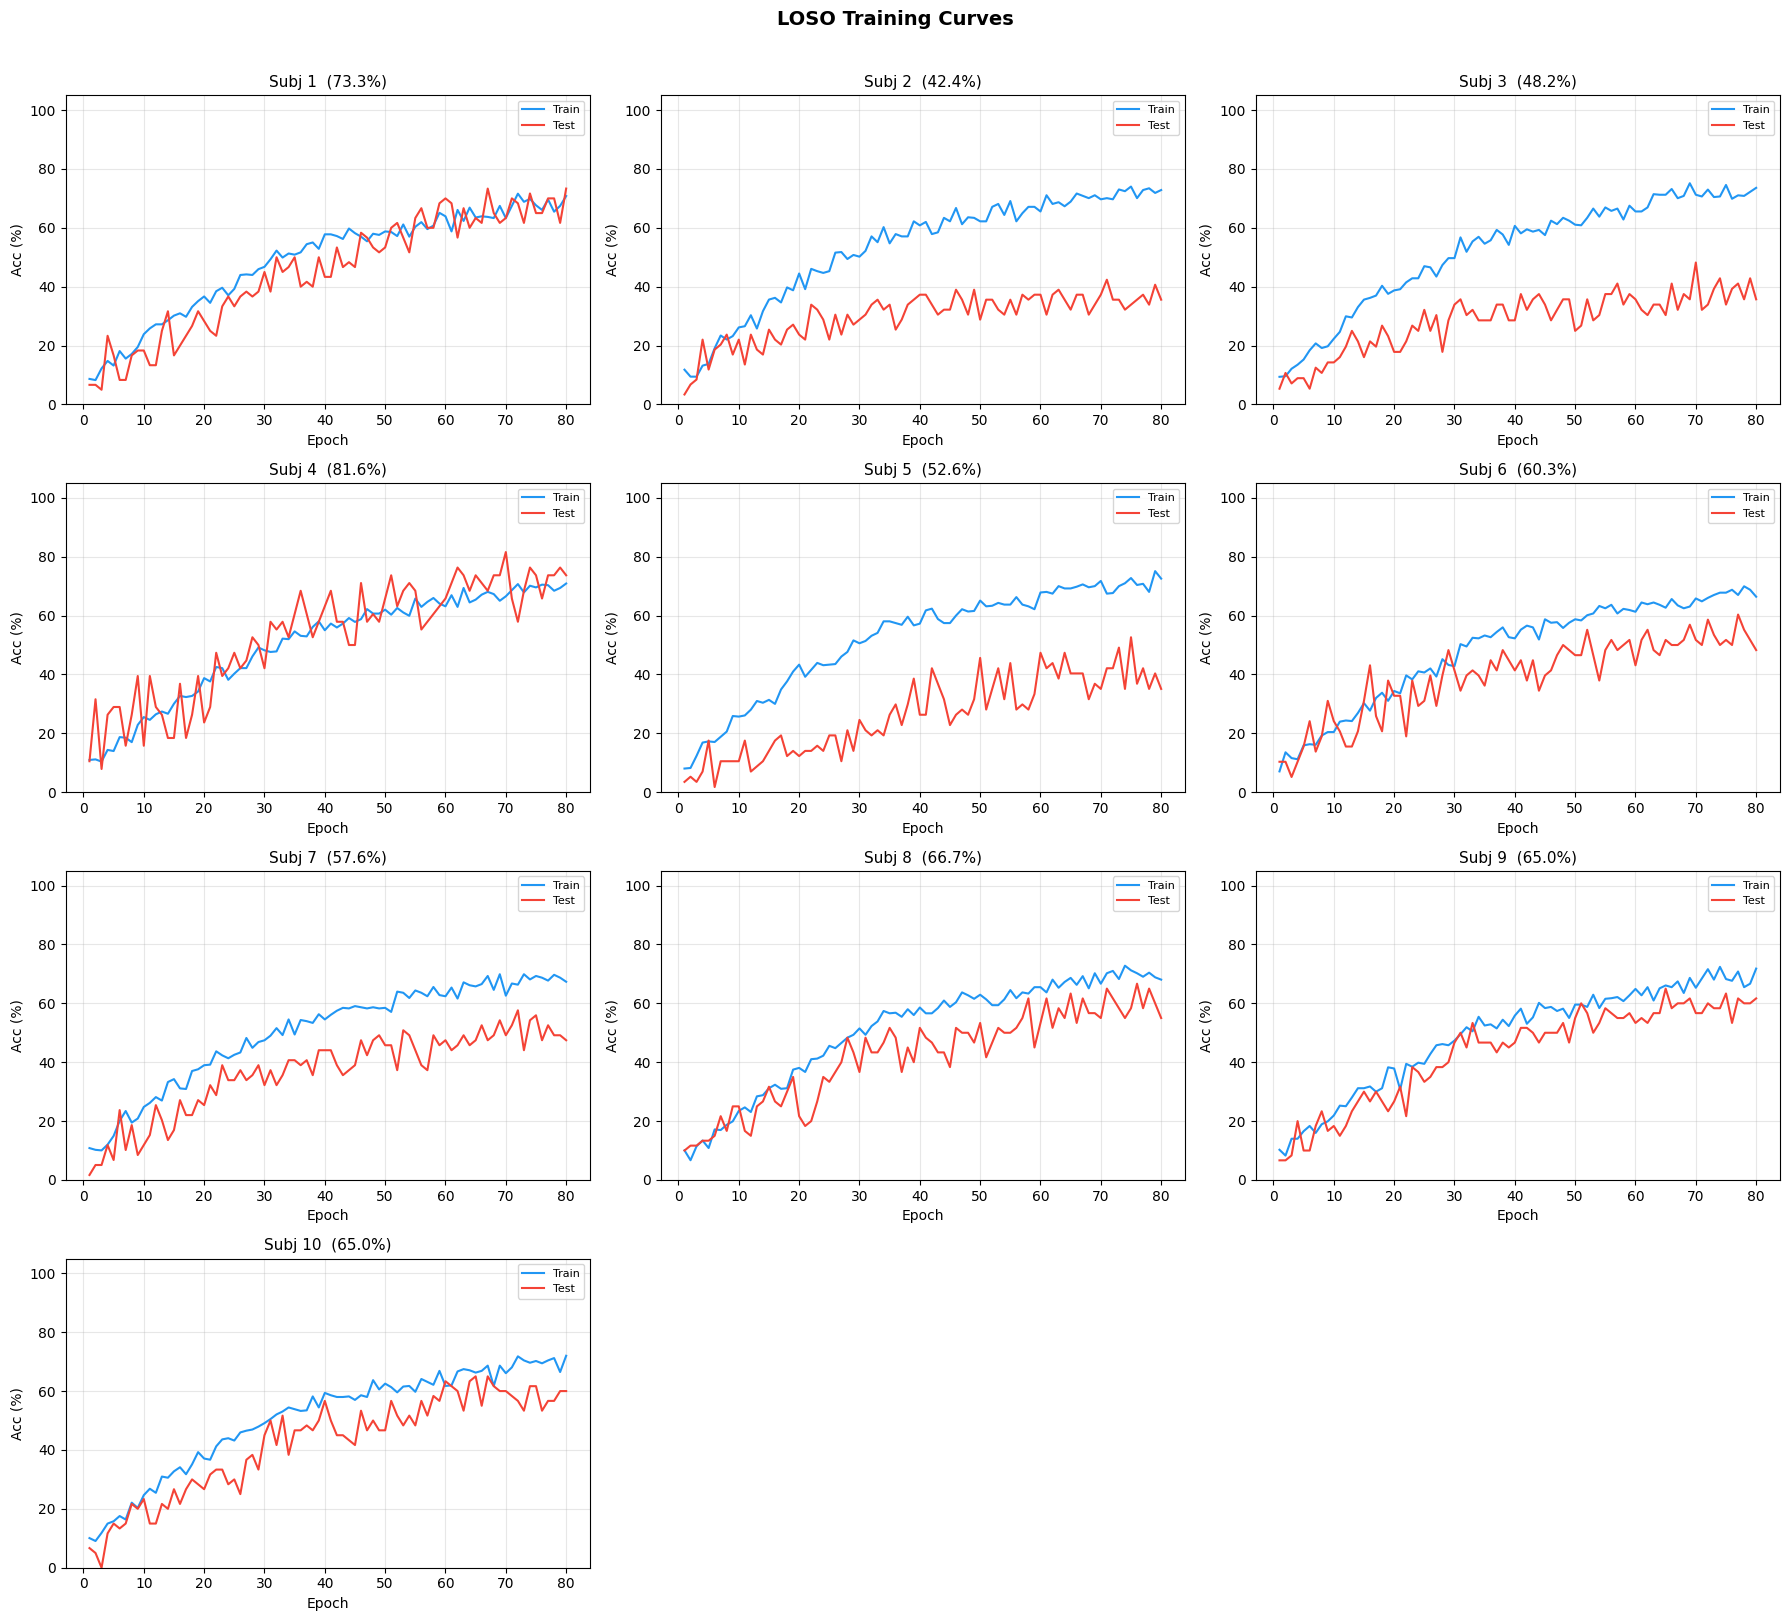

In [13]:
# Training Curves Grid
n = len(fold_histories)
ncols = min(3, n)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = np.array([axes]).flatten() if n == 1 else axes.flatten()

for idx, subj in enumerate(sorted(fold_histories)):
    ax = axes[idx]
    h  = fold_histories[subj]
    ep = range(1, len(h["train_acc"]) + 1)
    ax.plot(ep, [a*100 for a in h["train_acc"]], label="Train", color="#2196F3", lw=1.5)
    ax.plot(ep, [a*100 for a in h["test_acc"]],  label="Test",  color="#F44336", lw=1.5)
    ax.set_title(f"Subj {subj}  ({loso_results[subj]['accuracy']:.1%})", fontsize=11)
    ax.set_xlabel("Epoch"); ax.set_ylabel("Acc (%)"); ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3); ax.set_ylim(0, 105)

for idx in range(n, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("LOSO Training Curves", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "loso_training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

## 12. Aggregated Evaluation Metrics & Confusion Matrix

In [14]:
# Aggregated Metrics & Classification Report

unique_labels = sorted(set(all_fold_labels) | set(all_fold_preds))
target_names  = [ACTION_NAMES[i] for i in unique_labels]

print("=" * 60)
print("AGGREGATED EVALUATION  (All LOSO Folds Pooled)")
print("=" * 60)
print(f"Overall Accuracy : {overall_acc:.2%}")
print(f"Mean Fold Acc    : {mean_acc:.2%} ± {std_acc:.2%}")
print(f"Precision (macro): {precision_score(all_fold_labels, all_fold_preds, average='macro', zero_division=0):.4f}")
print(f"Recall    (macro): {recall_score   (all_fold_labels, all_fold_preds, average='macro', zero_division=0):.4f}")
print(f"F1-Score  (macro): {f1_score       (all_fold_labels, all_fold_preds, average='macro', zero_division=0):.4f}")
print()
print(classification_report(all_fold_labels, all_fold_preds,
                             labels=unique_labels, target_names=target_names, zero_division=0))

AGGREGATED EVALUATION  (All LOSO Folds Pooled)
Overall Accuracy : 60.67%
Mean Fold Acc    : 61.28% ± 11.10%
Precision (macro): 0.6018
Recall    (macro): 0.6034
F1-Score  (macro): 0.5877

                     precision    recall  f1-score   support

      High Arm Wave       0.80      0.44      0.57        27
Horizontal Arm Wave       0.62      0.59      0.60        27
             Hammer       0.55      0.44      0.49        27
         Hand Catch       0.63      0.46      0.53        26
      Forward Punch       0.08      0.04      0.05        26
         High Throw       0.73      0.42      0.54        26
             Draw X       0.46      0.21      0.29        28
          Draw Tick       0.44      0.63      0.52        30
        Draw Circle       0.38      0.57      0.45        30
          Hand Clap       0.65      0.67      0.66        30
      Two Hand Wave       0.81      0.87      0.84        30
        Side Boxing       0.72      0.77      0.74        30
               Bend

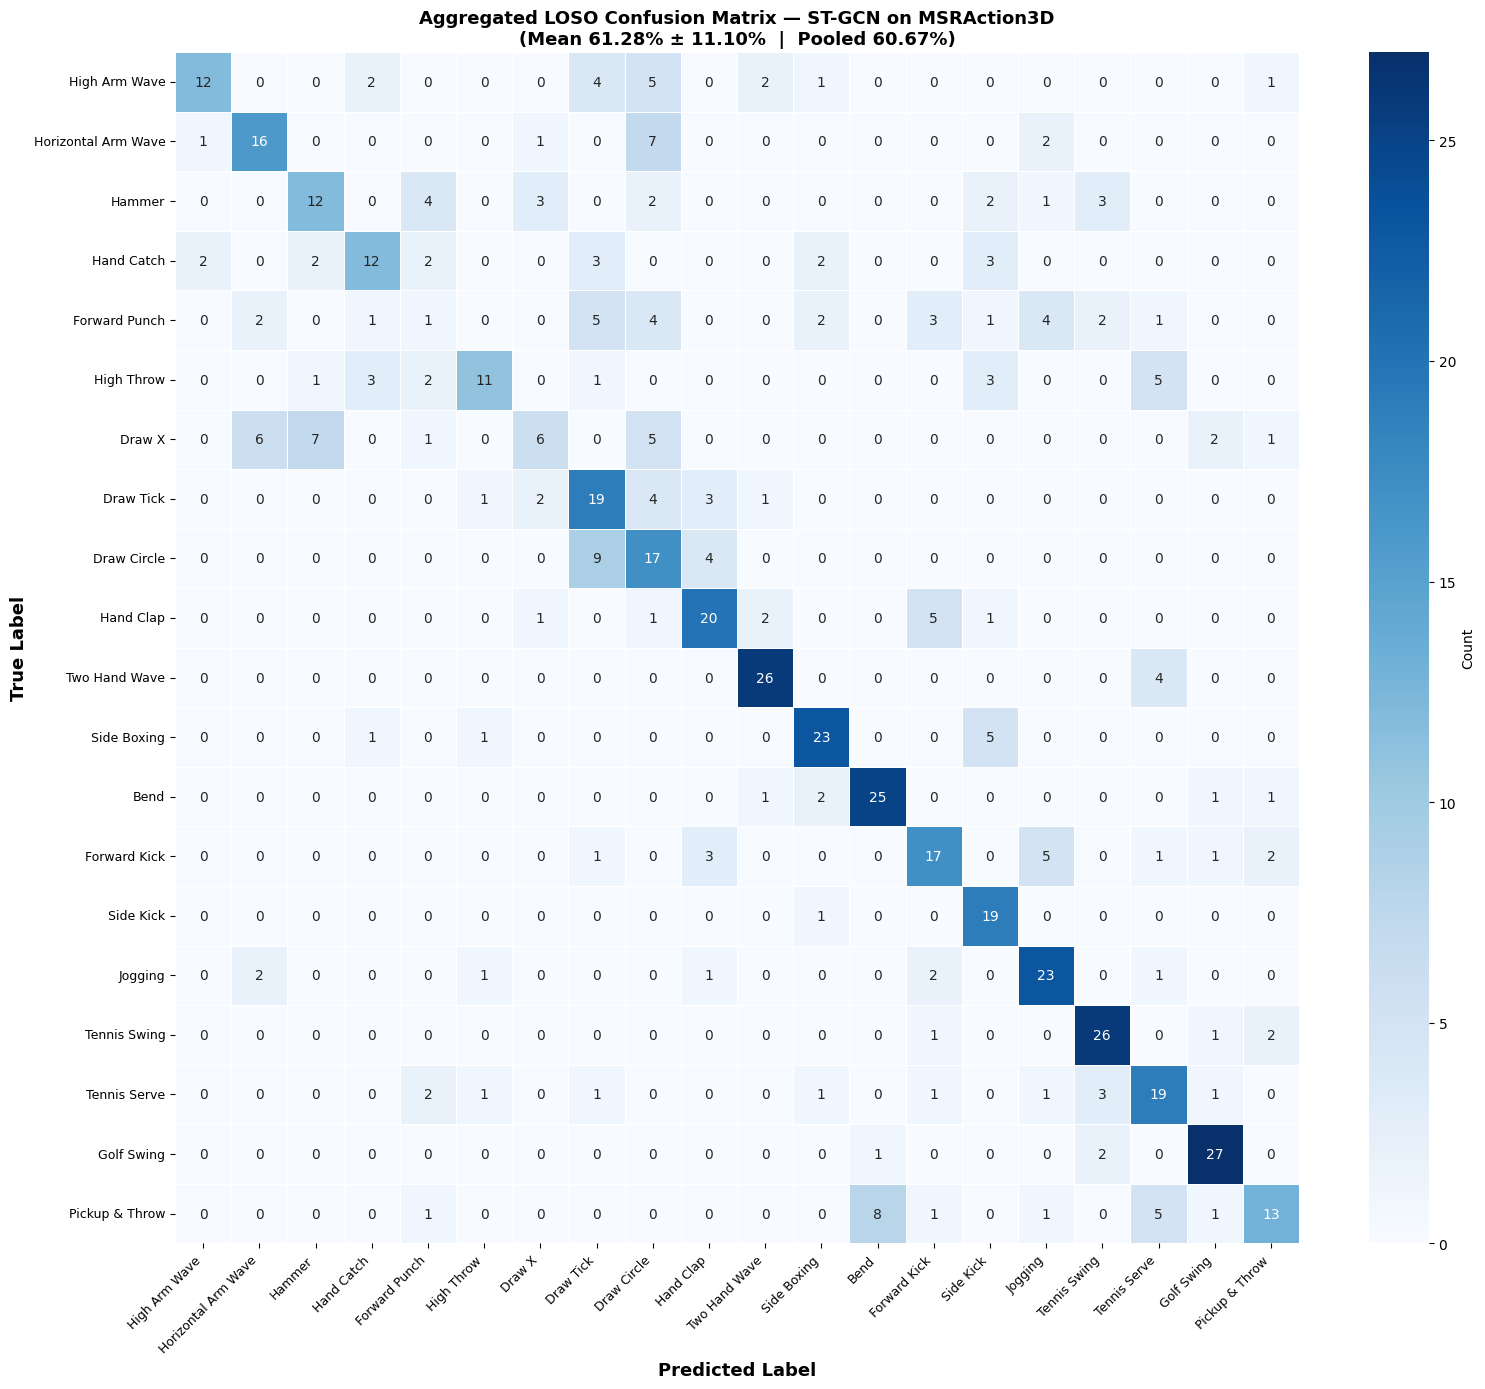

In [15]:
# Confusion Matrix

cm = confusion_matrix(all_fold_labels, all_fold_preds, labels=unique_labels)

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names,
            ax=ax, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted Label", fontsize=13, fontweight="bold")
ax.set_ylabel("True Label",      fontsize=13, fontweight="bold")
ax.set_title(
    f"Aggregated LOSO Confusion Matrix — ST-GCN on MSRAction3D\n"
    f"(Mean {mean_acc:.2%} ± {std_acc:.2%}  |  Pooled {overall_acc:.2%})",
    fontsize=13, fontweight="bold",
)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "loso_confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

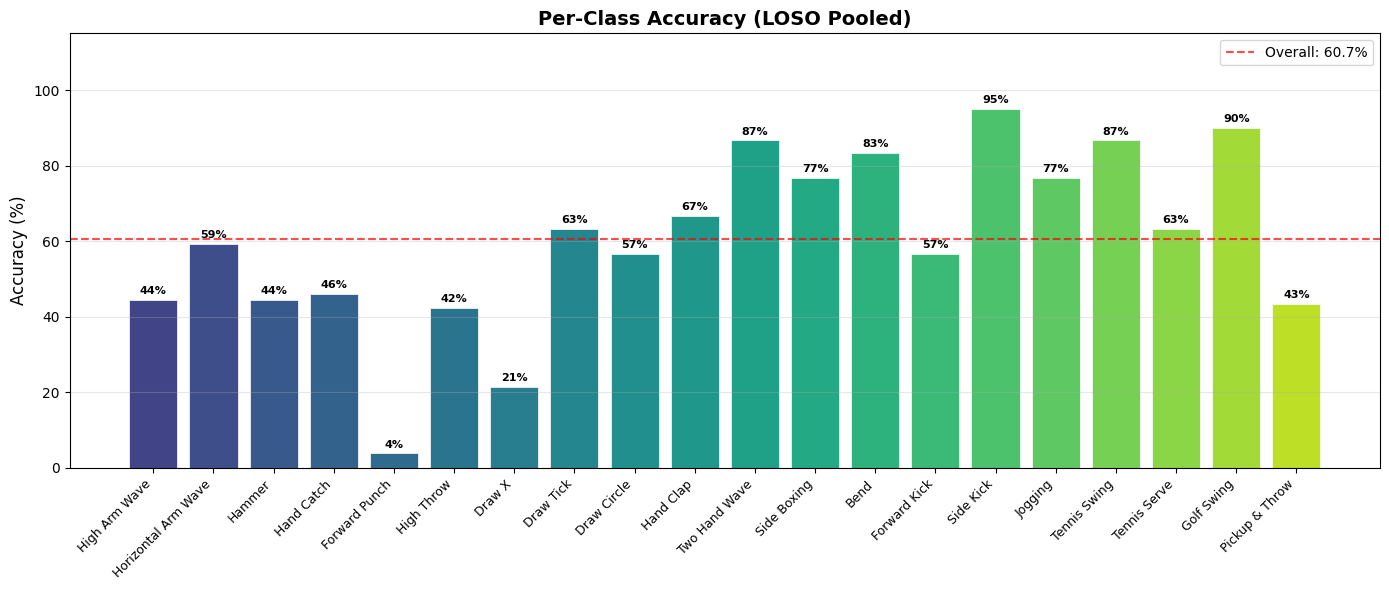

In [16]:
# Per-Class Accuracy Bar Chart

per_class_acc = cm.diagonal() / cm.sum(axis=1).clip(min=1)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(target_names)))

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(range(len(target_names)), per_class_acc * 100,
              color=colors, edgecolor="white", linewidth=0.5)
for bar, acc in zip(bars, per_class_acc):
    if acc > 0:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f"{acc:.0%}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(range(len(target_names)))
ax.set_xticklabels(target_names, rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("Per-Class Accuracy (LOSO Pooled)", fontsize=14, fontweight="bold")
ax.set_ylim(0, 115)
ax.axhline(overall_acc * 100, color="red", linestyle="--", alpha=0.7,
           label=f"Overall: {overall_acc:.1%}")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "loso_per_class_accuracy.png"), dpi=150, bbox_inches="tight")
plt.show()

## 13. Visualize a Sample Skeleton Sequence

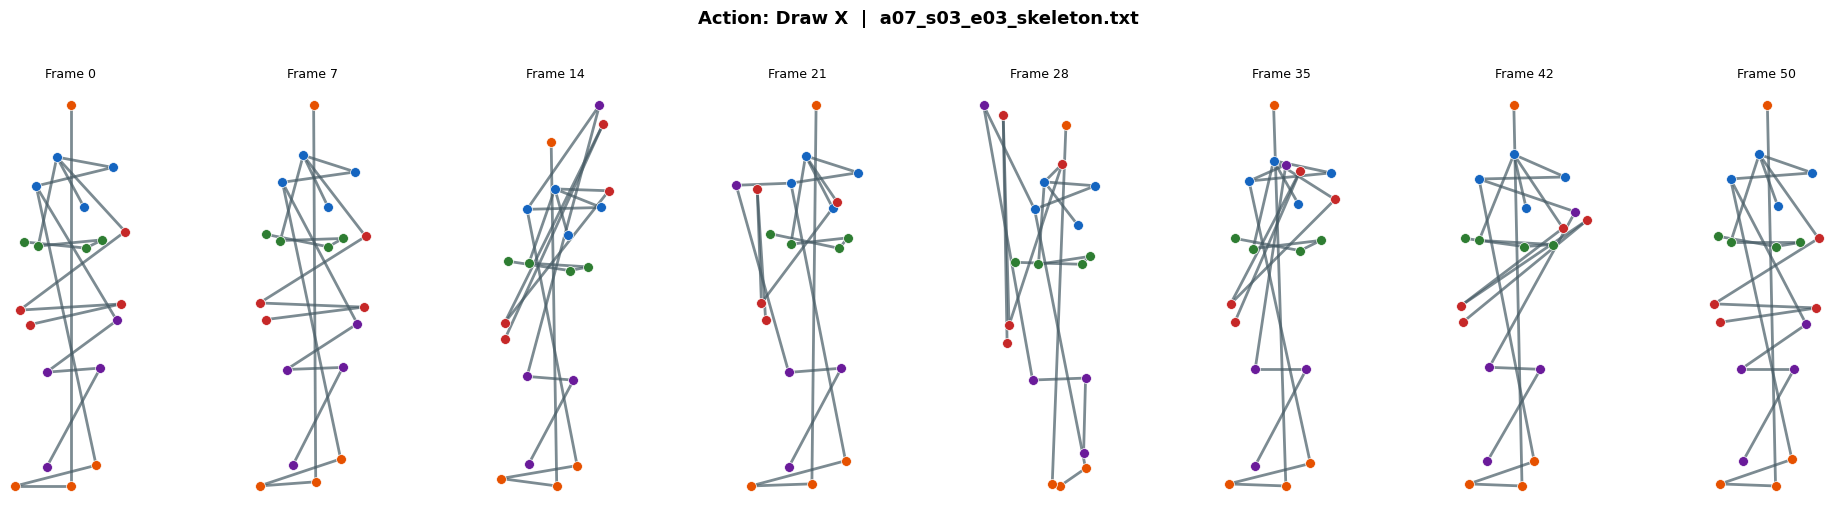

In [17]:
# 2D Skeleton Sequence Visualization

def visualize_skeleton_2d(sample, num_frames=8, title=None):
    pos    = sample["position"]
    action = sample["action"]
    fname  = sample["filename"]

    frame_norms = np.linalg.norm(pos.reshape(pos.shape[0], -1), axis=1)
    actual_len  = max(np.sum(frame_norms > 1e-6), num_frames)
    frame_idx   = np.linspace(0, actual_len - 1, num_frames, dtype=int)

    bones = [
        (0,1),(1,2),(2,3),(2,4),(4,5),(5,6),(6,7),
        (2,8),(8,9),(9,10),(10,11),(0,12),(12,13),
        (13,14),(14,15),(0,16),(16,17),(17,18),(18,19),
    ]
    jcolors = (
        ["#1565C0"]*4 + ["#2E7D32"]*4 + ["#C62828"]*4 +
        ["#6A1B9A"]*4 + ["#E65100"]*4
    )

    fig, axes = plt.subplots(1, num_frames, figsize=(num_frames * 2.5, 5))
    if num_frames == 1: axes = [axes]
    fig.suptitle(title or f"Action: {ACTION_NAMES[action]}  |  {fname}",
                 fontsize=13, fontweight="bold", y=1.02)

    for ax, fi in zip(axes, frame_idx):
        j = pos[fi]
        xs, ys = j[:, 0], -j[:, 1]
        for s, d in bones:
            ax.plot([xs[s], xs[d]], [ys[s], ys[d]], color="#455A64", lw=2, alpha=0.7)
        for ji in range(NUM_JOINTS):
            ax.scatter(xs[ji], ys[ji], c=jcolors[ji], s=50, zorder=5,
                       edgecolors="white", linewidth=0.5)
        ax.set_title(f"Frame {fi}", fontsize=9)
        ax.set_aspect("equal"); ax.axis("off")

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "skeleton_visualization.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

visualize_skeleton_2d(all_samples[0])

## 14. 3D Skeleton Visualization

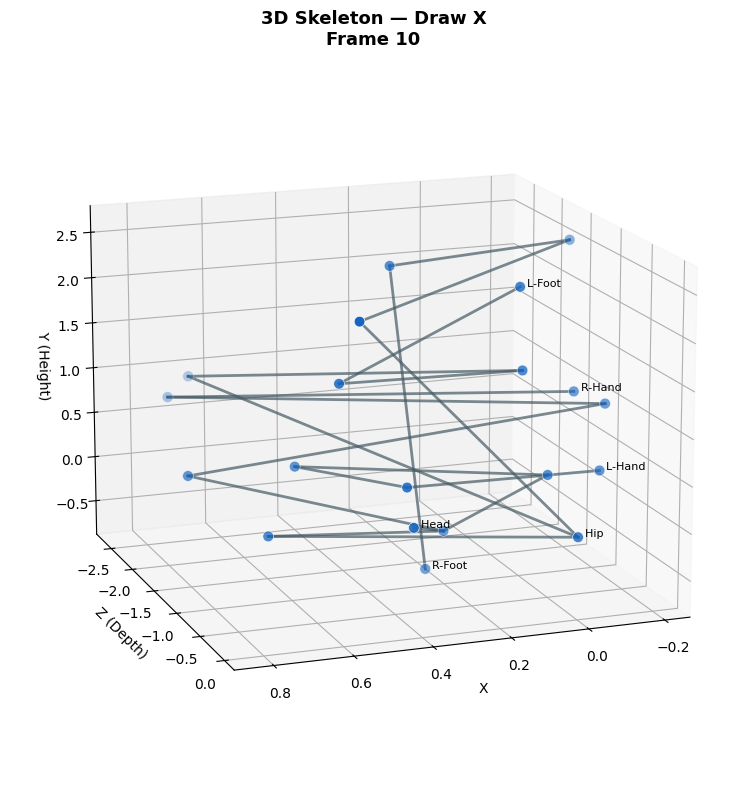

In [19]:
#  3D Skeleton Visualization

def visualize_skeleton_3d(sample, frame_idx=10):
    pos    = sample["position"]
    joints = pos[frame_idx]
    action = sample["action"]

    bones = [
        (0,1),(1,2),(2,3),(2,4),(4,5),(5,6),(6,7),
        (2,8),(8,9),(9,10),(10,11),(0,12),(12,13),
        (13,14),(14,15),(0,16),(16,17),(17,18),(18,19),
    ]

    fig = plt.figure(figsize=(8, 8))
    ax  = fig.add_subplot(111, projection="3d")

    for s, d in bones:
        ax.plot3D([joints[s,0], joints[d,0]],
                  [joints[s,2], joints[d,2]],
                  [joints[s,1], joints[d,1]],
                  color="#455A64", lw=2, alpha=0.7)

    ax.scatter3D(joints[:,0], joints[:,2], joints[:,1],
                 c="#1565C0", s=60, edgecolors="white", linewidth=0.5, zorder=5)

    for jid, name in {0:"Hip",3:"Head",7:"L-Hand",11:"R-Hand",15:"L-Foot",19:"R-Foot"}.items():
        ax.text(joints[jid,0], joints[jid,2], joints[jid,1], f"  {name}", fontsize=8)

    ax.set_xlabel("X"); ax.set_ylabel("Z (Depth)"); ax.set_zlabel("Y (Height)")
    ax.set_title(f"3D Skeleton — {ACTION_NAMES[action]}\nFrame {frame_idx}",
                 fontsize=13, fontweight="bold")
    ax.view_init(elev=15, azim=70)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "skeleton_3d.png"), dpi=150, bbox_inches="tight")
    plt.show()

visualize_skeleton_3d(all_samples[0], frame_idx=10)

## 15. Summary

### What was implemented:
1. **Data loading & preprocessing**: Parsed MSRAction3D skeleton files (20 joints x xyz)
2. **Normalization**: Centered skeletons at hip/spine, scaled to unit variance
3. **Velocity features**: Computed frame-to-frame differences as motion cues
4. **Human body graph**: Built a 20-node graph with natural body adjacency + self-loops
5. **ST-GCN model**: Spatial GCN (per-frame) + Temporal Conv (across frames) with residual connections
6. **LOSO Cross-Validation**: Leave-One-Subject-Out with fresh model per fold
7. **Evaluation**: Accuracy, precision, recall, F1, confusion matrix, per-class & per-subject accuracy
8. **Visualization**: 2D and 3D skeleton renderings with bone connections

### LOSO Protocol:
- All subjects (1-10, including 4) are used
- Each fold leaves one subject out for testing
- A fresh model is trained from scratch for each fold
- Results are pooled and averaged across all folds

In [20]:
#  Final Summary

print("=" * 55)
print("  LOSO RESULTS SUMMARY")
print("=" * 55)
print(f"  Folds          : {num_folds}")
print(f"  Mean Accuracy  : {mean_acc:.2%} ± {std_acc:.2%}")
print(f"  Pooled Accuracy: {overall_acc:.2%}")
print()
print("  Saved outputs:")
for fname in [
    "loso_per_subject_accuracy.png",
    "loso_training_curves.png",
    "loso_confusion_matrix.png",
    "loso_per_class_accuracy.png",
    "skeleton_visualization.png",
    "skeleton_3d.png",
]:
    print(f"    /kaggle/working/{fname}")

  LOSO RESULTS SUMMARY
  Folds          : 10
  Mean Accuracy  : 61.28% ± 11.10%
  Pooled Accuracy: 60.67%

  Saved outputs:
    /kaggle/working/loso_per_subject_accuracy.png
    /kaggle/working/loso_training_curves.png
    /kaggle/working/loso_confusion_matrix.png
    /kaggle/working/loso_per_class_accuracy.png
    /kaggle/working/skeleton_visualization.png
    /kaggle/working/skeleton_3d.png


In [ ]:
import shutil

shutil.make_archive('/kaggle/working', 'zip', '/kaggle/working')
print("done")

'/kaggle/working.zip'